# Business Understanding

## Project Domain

> Domain: Healthcare & Medical Diagnostics<br>
> Sub-Domain: Preventive Healthcare & Clinical Decision Support Systems

Sistem deteksi risiko stroke (Stroke Risk Prediction System) termasuk dalam bidang preventive healthcare yang memanfaatkan data science dan machine learning untuk membantu tenaga medis atau individu dalam mengidentifikasi potensi risiko stroke sejak dini. Dengan mempertimbangkan berbagai faktor seperti usia, tekanan darah, kadar glukosa, indeks massa tubuh (BMI), riwayat merokok, serta kondisi medis lainnya, sistem ini bertujuan memberikan dukungan pengambilan keputusan klinis (clinical decision support system) yang lebih tepat dan berbasis data.

## Problem Statements

Masalah yang Dihadapi:

1. Kurangnya Deteksi Dini Risiko Stroke

  * Banyak individu tidak menyadari bahwa mereka memiliki faktor risiko stroke seperti hipertensi, diabetes, atau kebiasaan merokok.

  * Deteksi yang terlambat dapat menyebabkan keterlambatan dalam penanganan medis yang krusial.

2. Akses Terbatas ke Diagnosis Medis Awal

  * Pemeriksaan rutin yang komprehensif memerlukan biaya dan akses ke fasilitas kesehatan, yang sering kali tidak terjangkau bagi masyarakat di daerah terpencil.

3. Keputusan Medis yang Kurang Berbasis Data

  * Dalam beberapa kasus, diagnosis dini hanya mengandalkan observasi subjektif tanpa dukungan sistem berbasis data yang dapat memvalidasi potensi risiko secara obyektif.

4. Minimnya Alat Prediksi yang Mudah Diakses

  * Belum tersedia sistem berbasis web yang ringan, cepat, dan dapat digunakan oleh masyarakat umum maupun tenaga kesehatan untuk memperkirakan risiko stroke.



## Goals
Membangun sistem berbasis AI (Artificial Neural Network) yang dapat memprediksi risiko stroke berdasarkan parameter:

1. Data Demografis & Gaya Hidup: Jenis kelamin, usia, status pernikahan, status merokok
2. Kondisi Kesehatan: Hipertensi, penyakit jantung, kadar glukosa, BMI
3. Faktor Sosial & Lingkungan: Jenis pekerjaan, lokasi tempat tinggal




## Solution Statements
🔹 Machine Learning Model
Menggunakan Artificial Neural Network (ANN) untuk klasifikasi individu berdasarkan potensi risiko stroke.
Model dilatih menggunakan dataset kesehatan dengan target prediksi: apakah seseorang berisiko mengalami stroke.

🔹 Aplikasi Web (Streamlit)
Membangun antarmuka pengguna berbasis Streamlit yang intuitif dan mudah digunakan, memungkinkan pengguna memasukkan data sederhana untuk mendapatkan hasil prediksi secara instan.

🔹 Optimasi dengan TensorFlow Lite
Model dikonversi ke format TFLite agar efisien dan dapat dijalankan di perangkat dengan spesifikasi rendah, seperti smartphone atau komputer di klinik daerah terpencil.

# Data Understanding

In [1]:
# prepping
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## Import Library yang Dibutuhkan

In [2]:
# Imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# file = "/content/d_output.csv"
df = pd.read_csv('/content/cleaned_healthcare-dataset-stroke-data.csv')
df.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1828,41911,Female,21.0,0,0,Yes,Private,Rural,149.90,23.4,Unknown,0
2876,72525,Female,39.0,0,0,Yes,Private,Urban,90.31,27.6,smokes,0
1667,38578,Female,35.0,0,0,No,Private,Urban,71.81,25.4,Unknown,0
1879,11450,Female,41.0,0,0,Yes,Self-employed,Urban,98.85,24.6,never smoked,0
4247,63773,Female,13.0,0,0,No,children,Rural,146.10,22.8,never smoked,0


## Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4908 entries, 0 to 4907
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4908 non-null   int64  
 1   gender             4908 non-null   object 
 2   age                4908 non-null   float64
 3   hypertension       4908 non-null   int64  
 4   heart_disease      4908 non-null   int64  
 5   ever_married       4908 non-null   object 
 6   work_type          4908 non-null   object 
 7   Residence_type     4908 non-null   object 
 8   avg_glucose_level  4908 non-null   float64
 9   bmi                4908 non-null   float64
 10  smoking_status     4908 non-null   object 
 11  stroke             4908 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 460.3+ KB


# Data Preparation

## 1. Hapus Kolom "id" & Encode Kolom Bernilai Kategorikal

In [5]:
# hapus kolom 'id'
df.drop(columns=['id'], inplace=True)

In [6]:
# Daftar kolom kategorikal
categorical_columns = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    le.fit(df[col])  # df[col] harus berupa teks asli seperti 'Male', 'Female'
    label_encoders[col] = le

for col in categorical_columns:
    df[col] = label_encoders[col].transform(df[col])

In [7]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,1,80.0,0,1,1,2,0,105.92,32.5,2,1
2,0,49.0,0,0,1,2,1,171.23,34.4,3,1
3,0,79.0,1,0,1,3,0,174.12,24.0,2,1
4,1,81.0,0,0,1,2,1,186.21,29.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4903,0,13.0,0,0,0,4,0,103.08,18.6,0,0
4904,0,81.0,0,0,1,3,1,125.20,40.0,2,0
4905,0,35.0,0,0,1,3,0,82.99,30.6,2,0
4906,1,51.0,0,0,1,2,0,166.29,25.6,1,0


## 2. Pisahkan fitur dan target

In [8]:
# pisahkan fitur dan target
X = df.drop(columns=["stroke"])
y = df["stroke"]

In [9]:
# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [10]:
X

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1,67.0,0,1,1,2,1,228.69,36.6,1
1,1,80.0,0,1,1,2,0,105.92,32.5,2
2,0,49.0,0,0,1,2,1,171.23,34.4,3
3,0,79.0,1,0,1,3,0,174.12,24.0,2
4,1,81.0,0,0,1,2,1,186.21,29.0,1
...,...,...,...,...,...,...,...,...,...,...
4903,0,13.0,0,0,0,4,0,103.08,18.6,0
4904,0,81.0,0,0,1,3,1,125.20,40.0,2
4905,0,35.0,0,0,1,3,0,82.99,30.6,2
4906,1,51.0,0,0,1,2,0,166.29,25.6,1


## 3. Normalisasi Fitur

In [11]:
# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

## 4. Splitting Train & Test Set

In [12]:
# Bagi data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [13]:
model = Sequential()
model.add(Dense(14,input_dim=10,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(loss="binary_crossentropy",
              optimizer='SGD',
              metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           154 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283 (1.11 KB)

 Trainable params: 283 (1.11 KB)

 Non-trainable params: 0 (0.00 B)

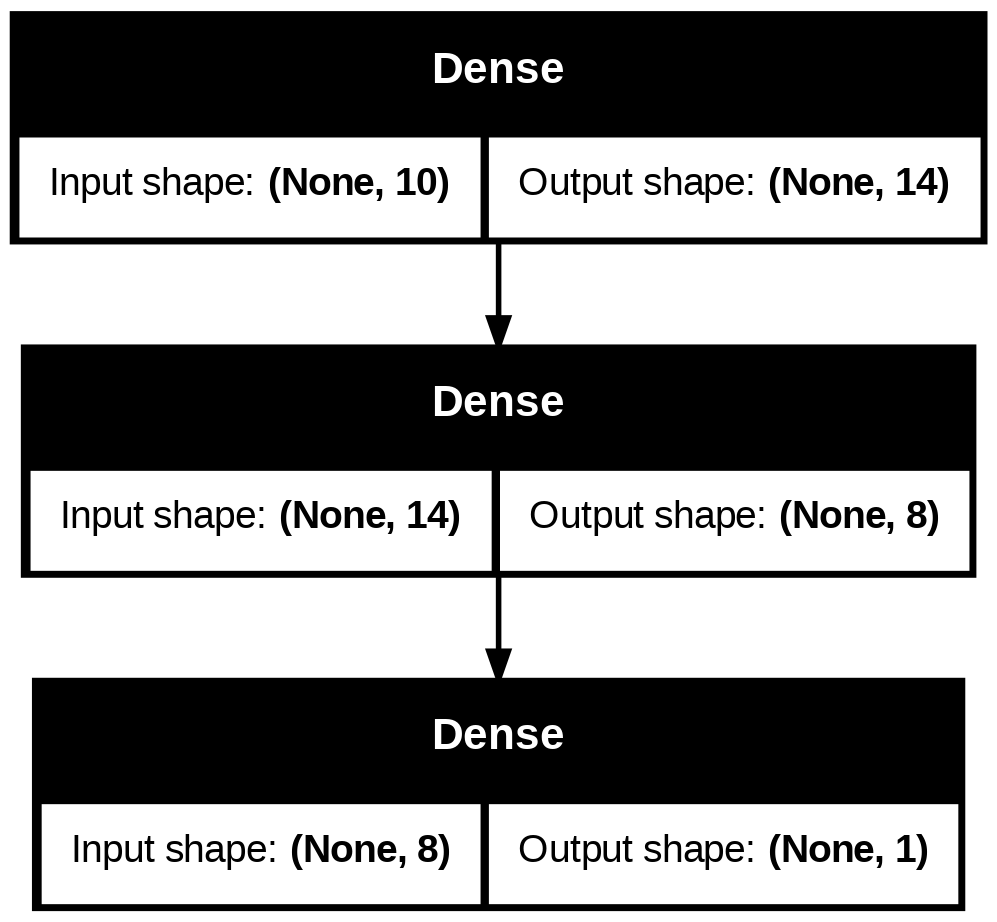

In [16]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [17]:
history = model.fit(X_train, y_train,
                    epochs=40,
                    batch_size=15,
                    validation_data=(X_test, y_test))

Epoch 1/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9599 - loss: 0.3960 - val_accuracy: 0.9460 - val_loss: 0.2377
Epoch 2/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9616 - loss: 0.1884 - val_accuracy: 0.9460 - val_loss: 0.2335
Epoch 3/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9585 - loss: 0.1929 - val_accuracy: 0.9460 - val_loss: 0.2299
Epoch 4/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9543 - loss: 0.2025 - val_accuracy: 0.9460 - val_loss: 0.2263
Epoch 5/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9566 - loss: 0.1906 - val_accuracy: 0.9460 - val_loss: 0.2232
Epoch 6/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9622 - loss: 0.1679 - val_accuracy: 0.9460 - val_loss: 0.2194
Epoch 7/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9593 - loss: 0.1746 - val_accuracy: 0.9460 - val_loss: 0.2163
Epoch 8/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9608 - loss: 0.1653 - val_accuracy: 0

# Evaluation

In [18]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9467 - loss: 0.1758
Akurasi Model: 0.9460
Loss Model: 0.1709


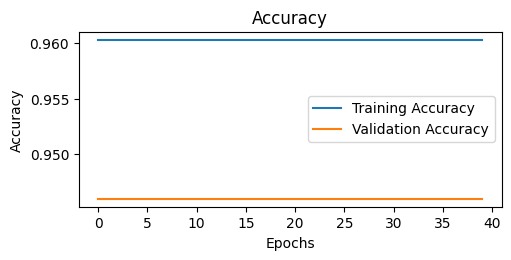

In [19]:
plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

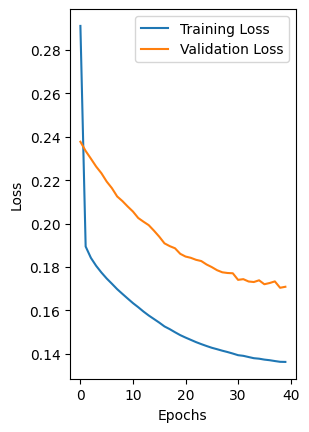

In [20]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


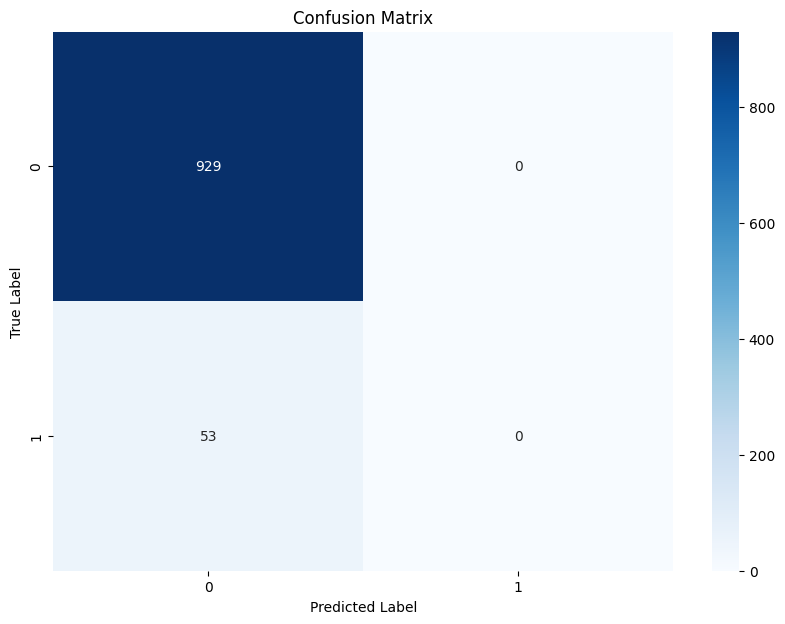

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       929
           1       0.00      0.00      0.00        53

    accuracy                           0.95       982
   macro avg       0.47      0.50      0.49       982
weighted avg       0.89      0.95      0.92       982



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [22]:
# Sample input yang disesuaikan
sample_input = pd.DataFrame([{
    'gender': '1',
    'age': 45.0,
    'hypertension': 1,
    'heart_disease': 0,
    'ever_married': '1',
    'work_type': '2',
    'Residence_type': '1',
    'avg_glucose_level': 105.6,
    'bmi': 26.4,
    'smoking_status': '0'
}])

In [23]:
sample_input_scaled = scaler.transform(sample_input)

In [24]:
label_mapping = {
       0: "No",
       1: "Yes"
   }
predicted_stroke = np.argmax(model.predict(sample_input_scaled))
# Gunakan label_mapping agar output berupa "Yes" atau "No"
predicted_label = label_mapping[predicted_stroke]

print(f"Hasil diagnosa: {predicted_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Hasil diagnosa: No


## Save Model

In [25]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('stroke_diagnosis.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpusaebwve'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137994632789072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992954945488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994632789264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994632789456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994633332112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137995250439696: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [26]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']